# Plasticity- vs Fitness-Selection in Morphologically Evolving Robots

| Label | Selection key |
|---|---|
| **Baseline** (green) | post-learning `fitness` |
| **ΔL-aware** (purple) | learning delta `fitness − fitness_pre` |


In [1]:

import re, ast, math, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

ROOT = Path("/Users/anfi/Documents/TFM_FINAL")
if not (ROOT / "experiment_data").exists():
    ROOT = Path.cwd()
EXP_DIR = ROOT / "experiment_data"
GEN_DIR = ROOT / "experiment_data_generalization"
FIG_DIR = ROOT / "thesis_figures"; FIG_DIR.mkdir(exist_ok=True)

BASE, LAW = "Baseline", "ΔL-aware"
SELECTIONS = [BASE, LAW]
COL = {BASE: "#2ca02c", LAW: "#9b59b6"}
SEL_FROM_TAG = {"fitness": BASE, "ldelta": LAW}

OBJ_ORDER  = ["initial_heading", "3p_tl", "turning"]
TERR_ORDER = ["simpleflat", "tilted", "crater"]
OBJ_LABEL  = {"initial_heading": "Initial heading", "3p_tl": "3-direction (3p_tl)", "turning": "Turning"}
TERR_LABEL = {"simpleflat": "Flat", "tilted": "Tilted", "crater": "Crater"}
TRAIN_TERR, TRAIN_OBJ = "simpleflat", "initial_heading"


In [2]:

def parse_list(s):
    if isinstance(s, (list, tuple)):
        return list(s)
    if s is None or (isinstance(s, float) and math.isnan(s)):
        return []
    try:
        return ast.literal_eval(s)
    except Exception:
        try:
            return [float(x) for x in re.findall(r"[-+]?[\d.eE+]+|[-+]?inf|nan", str(s))]
        except Exception:
            return []

def cliffs_delta(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    if a.size == 0 or b.size == 0:
        return np.nan
    return float(np.sign(a[:, None] - b[None, :]).mean())

def cliffs_label(d):
    if not np.isfinite(d):
        return "n/a"
    a = abs(d)
    mag = ("negligible" if a < 0.147 else "small" if a < 0.33
           else "medium" if a < 0.474 else "large")
    return f"{d:+.3f} ({mag})"

def paired_wilcoxon(x, y):
    x = np.asarray(x, float); y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 2 or np.allclose(x, y):
        return np.nan, np.nan
    try:
        s, p = stats.wilcoxon(x, y)
        return float(s), float(p)
    except Exception:
        return np.nan, np.nan

def holm(pvals):
    p = np.asarray(pvals, float)
    out = np.full_like(p, np.nan)
    idx = np.where(np.isfinite(p))[0]
    order = idx[np.argsort(p[idx])]
    m = len(order); prev = 0.0
    for rank, i in enumerate(order):
        adj = min(1.0, (m - rank) * p[i])
        prev = max(prev, adj); out[i] = prev
    return out


## 1 · Data loading

In [3]:

EVO_RE = re.compile(r"learning(\d+)_.*_ga_p2_(fitness|ldelta)_flat\.csv$")

def load_evolution():
    rows = []
    for f in sorted(EXP_DIR.glob("learning*_ga_p2_*_flat.csv")):
        m = EVO_RE.search(f.name)
        if not m:
            continue
        seed, tag = int(m.group(1)), m.group(2)
        df = pd.read_csv(f, usecols=["generation", "fitness", "fitness_pre", "measures"])
        meas = df["measures"].map(parse_list)
        df["branching"] = meas.map(lambda v: v[0] if len(v) > 0 else np.nan)
        df["limb_std"]  = meas.map(lambda v: v[1] if len(v) > 1 else np.nan)
        df["seed"] = seed
        df["selection"] = SEL_FROM_TAG[tag]
        rows.append(df.drop(columns=["measures"]))
    if not rows:
        raise FileNotFoundError(EXP_DIR)
    out = pd.concat(rows, ignore_index=True)
    out["ldelta"] = out["fitness"] - out["fitness_pre"]
    return out

evo = load_evolution()
evo_f = evo[np.isfinite(evo["fitness"]) & np.isfinite(evo["fitness_pre"])].copy()


In [4]:

GEN_RE = re.compile(r"learning(\d+)_.*_ga_p2_(fitness|ldelta)_flat_gen\.csv$")

def load_generalization():
    rows = []
    for f in sorted(GEN_DIR.glob("learning*_ga_p2_*_flat_gen.csv")):
        m = GEN_RE.search(f.name)
        if not m:
            continue
        seed, tag = int(m.group(1)), m.group(2)
        df = pd.read_csv(f, usecols=["source_rank", "terrain", "objective",
                                     "fitness_pre", "fitness"])
        df["seed"] = seed
        df["selection"] = SEL_FROM_TAG[tag]
        rows.append(df)
    if not rows:
        raise FileNotFoundError(GEN_DIR)
    out = pd.concat(rows, ignore_index=True)
    out["ldelta"] = out["fitness"] - out["fitness_pre"]
    return out

gen = load_generalization()
gen_f = gen[np.isfinite(gen["fitness"])].copy()


In [5]:

seedgen = (evo_f.groupby(["selection", "seed", "generation"])
           .agg(fit_mean=("fitness", "mean"), fit_max=("fitness", "max"),
                pre_mean=("fitness_pre", "mean"), ldelta_mean=("ldelta", "mean"),
                branch_mean=("branching", "mean"), branch_div=("branching", "std"),
                limb_mean=("limb_std", "mean"), limb_div=("limb_std", "std"))
           .reset_index())

def across_seed(metric):
    return (seedgen.groupby(["selection", "generation"])[metric]
            .agg(["mean", "sem"]).reset_index())

GEN_LAST = int(evo_f["generation"].max())
last = seedgen[seedgen["generation"] == GEN_LAST].copy()


## 2 · Evolutionary dynamics

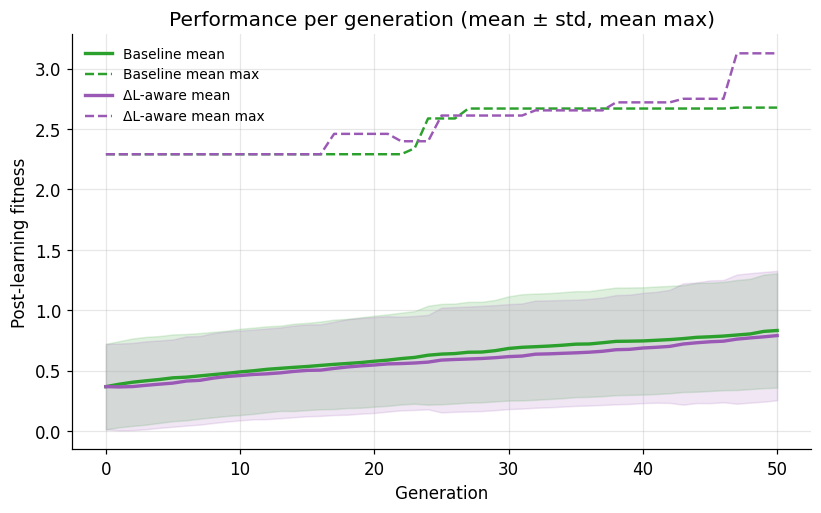

In [6]:

agg = evo_f.groupby(["selection", "generation"])["fitness"].agg(["mean", "std"]).reset_index()
mx = across_seed("fit_max")
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for sel in SELECTIONS:
    g = agg[agg.selection == sel]
    m = mx[mx.selection == sel]
    ax.plot(g.generation, g["mean"], color=COL[sel], lw=2.2, label=f"{sel} mean")
    ax.fill_between(g.generation, g["mean"] - g["std"], g["mean"] + g["std"], color=COL[sel], alpha=0.15)
    ax.plot(m.generation, m["mean"], color=COL[sel], lw=1.6, ls="--", label=f"{sel} mean max")
ax.set_xlabel("Generation"); ax.set_ylabel("Post-learning fitness")
ax.set_title("Performance per generation (mean ± std, mean max)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "perf_per_gen_std_max.pdf"); plt.show()


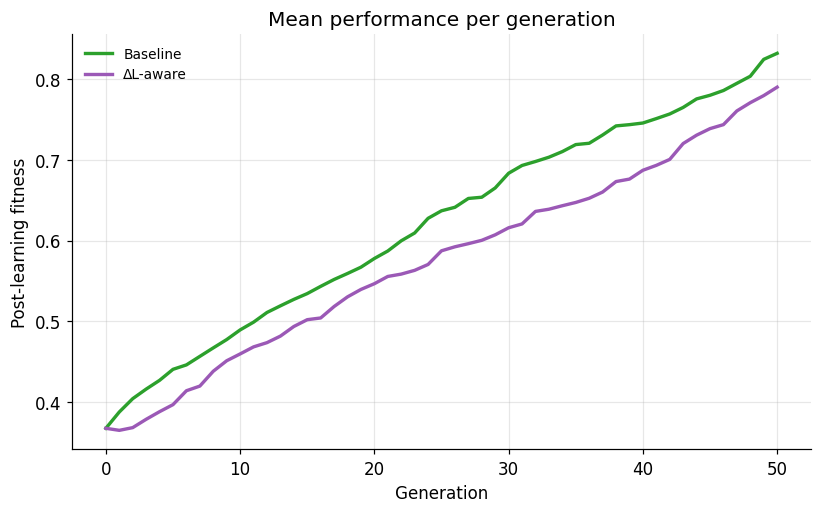

In [7]:

fig, ax = plt.subplots(figsize=(7.6, 4.8))
for sel in SELECTIONS:
    g = agg[agg.selection == sel]
    ax.plot(g.generation, g["mean"], color=COL[sel], lw=2.2, label=sel)
ax.set_xlabel("Generation"); ax.set_ylabel("Post-learning fitness")
ax.set_title("Mean performance per generation")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "perf_per_gen_mean.pdf"); plt.show()


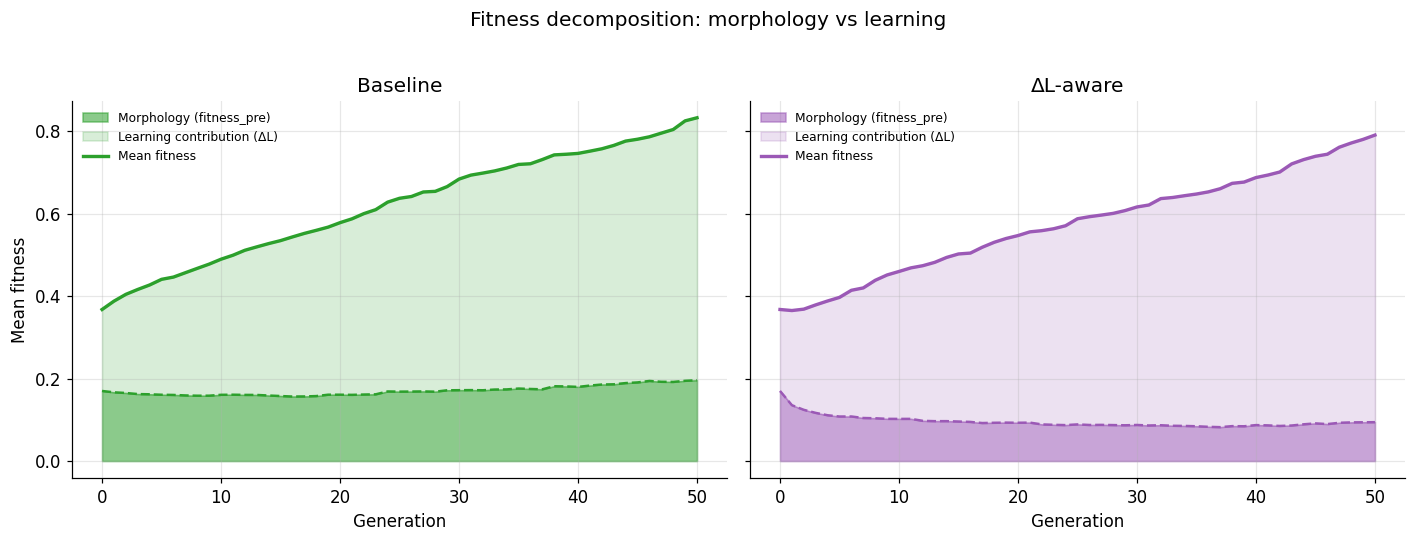

Baseline: pre-learning 24% of final  |  learning ΔL 76% of final
ΔL-aware: pre-learning 12% of final  |  learning ΔL 88% of final


In [8]:

dfm = evo_f.groupby(["selection", "generation"])[["fitness", "fitness_pre"]].mean().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
shares = {}
for ax, sel in zip(axes, SELECTIONS):
    g = dfm[dfm.selection == sel].sort_values("generation")
    gens, tot, pre = g.generation.values, g.fitness.values, g.fitness_pre.values
    ax.fill_between(gens, 0, pre, color=COL[sel], alpha=0.55, label="Morphology (fitness_pre)")
    ax.fill_between(gens, pre, tot, color=COL[sel], alpha=0.18, label="Learning contribution (ΔL)")
    ax.plot(gens, tot, color=COL[sel], lw=2.2, label="Mean fitness")
    ax.plot(gens, pre, color=COL[sel], lw=1.6, ls="--")
    shares[sel] = pre[-1] / tot[-1] if tot[-1] else float("nan")
    ax.set_title(sel); ax.set_xlabel("Generation")
axes[0].set_ylabel("Mean fitness")
for ax in axes:
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle("Fitness decomposition: morphology vs learning", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "decomposition.pdf"); plt.show()
for sel in SELECTIONS:
    s = shares[sel]
    print(f"{sel}: pre-learning {s:.0%} of final  |  learning ΔL {1 - s:.0%} of final")


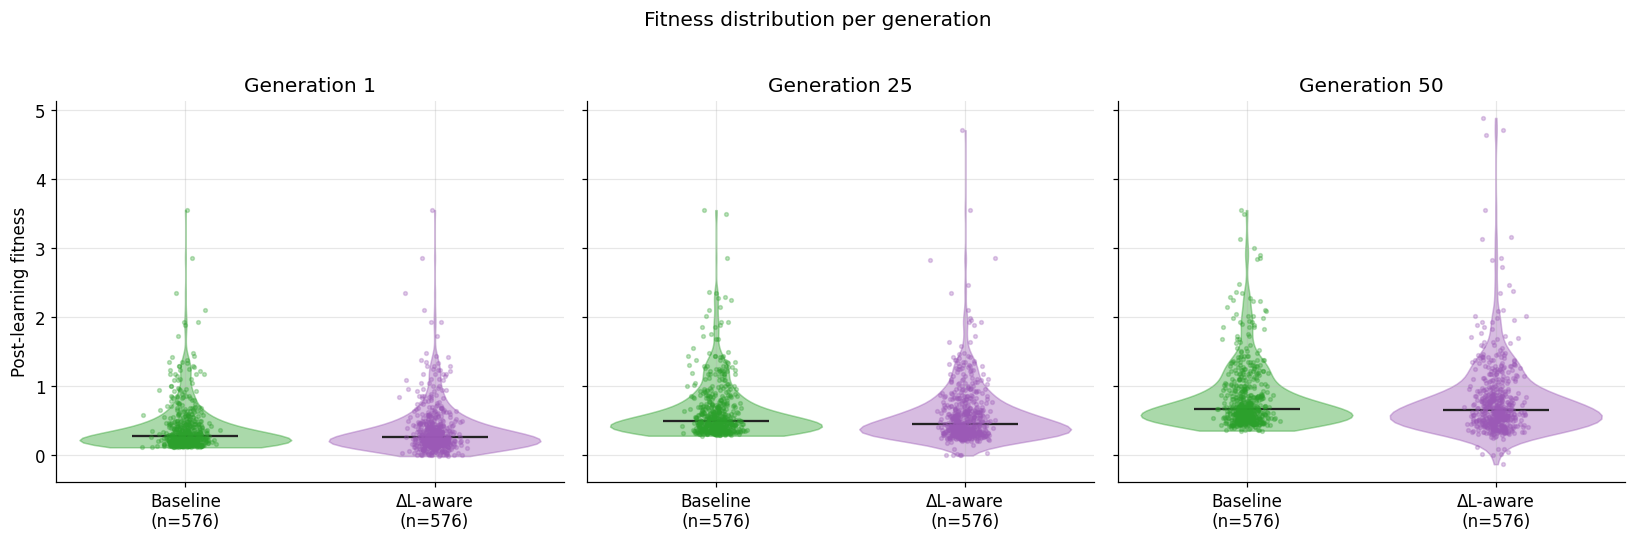

In [9]:

DIST_GENS = [1, 25, 50]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
rng_jit = np.random.default_rng(0)
for ax, gnum in zip(axes, DIST_GENS):
    data = [evo_f[(evo_f.selection == sel) & (evo_f.generation == gnum)]["fitness"].values
            for sel in SELECTIONS]
    parts = ax.violinplot(data, positions=[1, 2], widths=0.85, showmedians=True, showextrema=False)
    for body, sel in zip(parts["bodies"], SELECTIONS):
        body.set_facecolor(COL[sel]); body.set_alpha(0.40); body.set_edgecolor(COL[sel])
    if "cmedians" in parts:
        parts["cmedians"].set_color("#222"); parts["cmedians"].set_linewidth(1.5)
    for k, (v, sel) in enumerate(zip(data, SELECTIONS), start=1):
        ax.scatter(rng_jit.normal(k, 0.045, len(v)), v, s=6, color=COL[sel], alpha=0.30, zorder=3)
    ax.set_xticks([1, 2]); ax.set_xticklabels([f"{s}\n(n={len(d)})" for s, d in zip(SELECTIONS, data)])
    ax.set_title(f"Generation {gnum}")
axes[0].set_ylabel("Post-learning fitness")
fig.suptitle("Fitness distribution per generation", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "fitness_distribution_per_gen.pdf"); plt.show()

# 


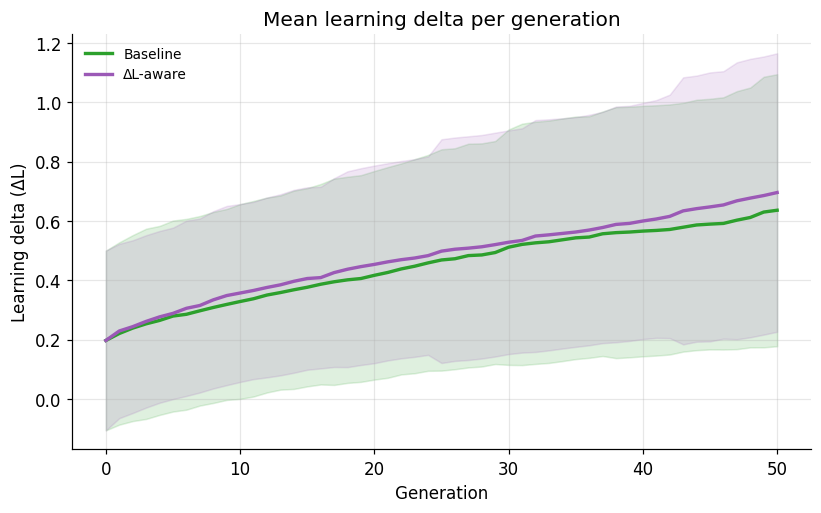

In [10]:

dfl = evo_f.groupby(["selection", "generation"])["ldelta"].agg(["mean", "std"]).reset_index()
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for sel in SELECTIONS:
    g = dfl[dfl.selection == sel]
    ax.plot(g.generation, g["mean"], color=COL[sel], lw=2.2, label=sel)
    ax.fill_between(g.generation, g["mean"] - g["std"], g["mean"] + g["std"], color=COL[sel], alpha=0.15)
ax.set_xlabel("Generation"); ax.set_ylabel("Learning delta (ΔL)")
ax.set_title("Mean learning delta per generation")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); fig.savefig(FIG_DIR / "ldelta_per_gen.pdf"); plt.show()


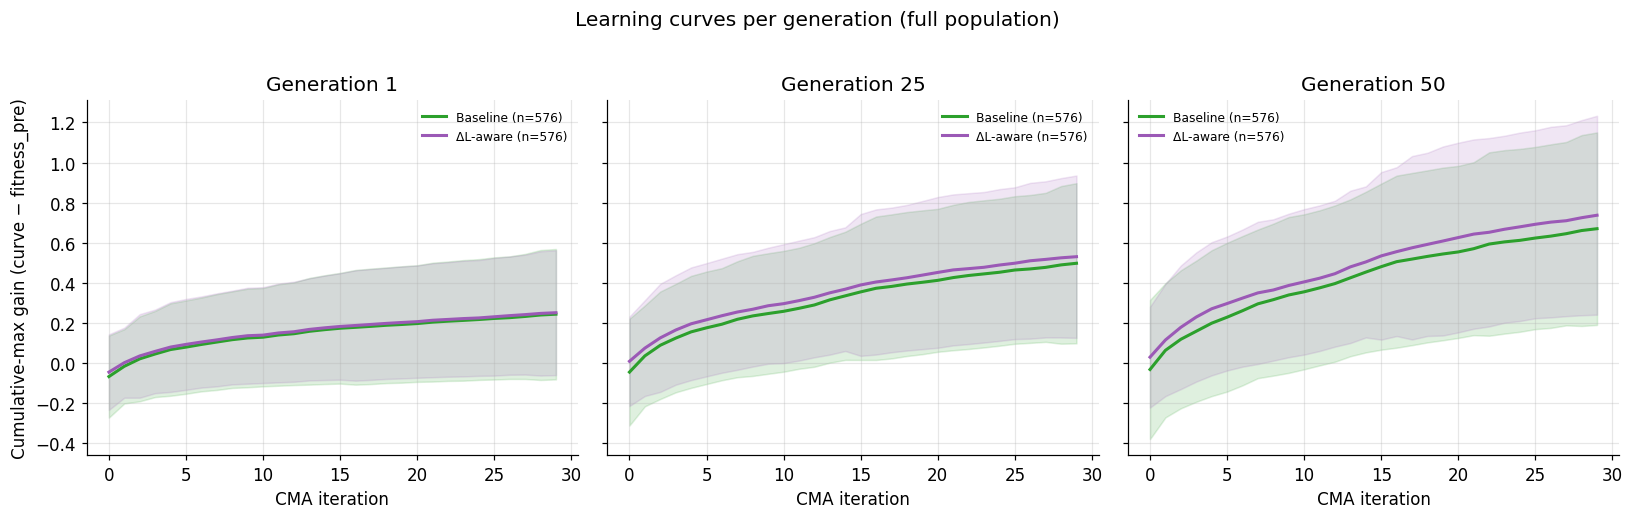

In [11]:

LC_GENS = [1, 25, 50]

def load_learning_curves(gens=LC_GENS):
    rows = []
    for f in sorted(EXP_DIR.glob("learning*_ga_p2_*_flat.csv")):
        m = EVO_RE.search(f.name)
        if not m:
            continue
        df = pd.read_csv(f, usecols=["generation", "fitness", "fitness_pre", "learning_curve"])
        df = df[df["generation"].isin(gens)].copy()
        if df.empty:
            continue
        df["curve"] = df["learning_curve"].map(parse_list)
        df["seed"] = int(m.group(1))
        df["selection"] = SEL_FROM_TAG[m.group(2)]
        rows.append(df.drop(columns=["learning_curve"]))
    return pd.concat(rows, ignore_index=True)

lc = load_learning_curves()

def plot_learning_curves(df, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
    for ax, gnum in zip(axes, LC_GENS):
        for sel in SELECTIONS:
            sub = df[(df.selection == sel) & (df.generation == gnum)]
            mats = []
            for _, r in sub.iterrows():
                c = np.asarray(r["curve"], dtype=float)
                c[(c <= -1e29) | ~np.isfinite(c)] = np.nan
                if np.all(np.isnan(c)):
                    continue
                mats.append(np.fmax.accumulate(c) - r["fitness_pre"])
            if not mats:
                continue
            L = max(len(g) for g in mats)
            arr = np.full((len(mats), L), np.nan)
            for i, g in enumerate(mats):
                arr[i, :len(g)] = g
                arr[i, len(g):] = g[-1]
            mean = np.nanmean(arr, axis=0); sd = np.nanstd(arr, axis=0)
            it = np.arange(L)
            ax.plot(it, mean, color=COL[sel], lw=2, label=f"{sel} (n={len(mats)})")
            ax.fill_between(it, mean - sd, mean + sd, color=COL[sel], alpha=0.15)
        ax.set_title(f"Generation {gnum}"); ax.set_xlabel("CMA iteration")
        ax.legend(frameon=False, fontsize=8)
    axes[0].set_ylabel("Cumulative-max gain (curve − fitness_pre)")
    fig.suptitle(title, y=1.02)
    fig.tight_layout(); fig.savefig(FIG_DIR / fname); plt.show()

plot_learning_curves(lc, "Learning curves per generation (full population)", "learning_curves_per_gen.pdf")


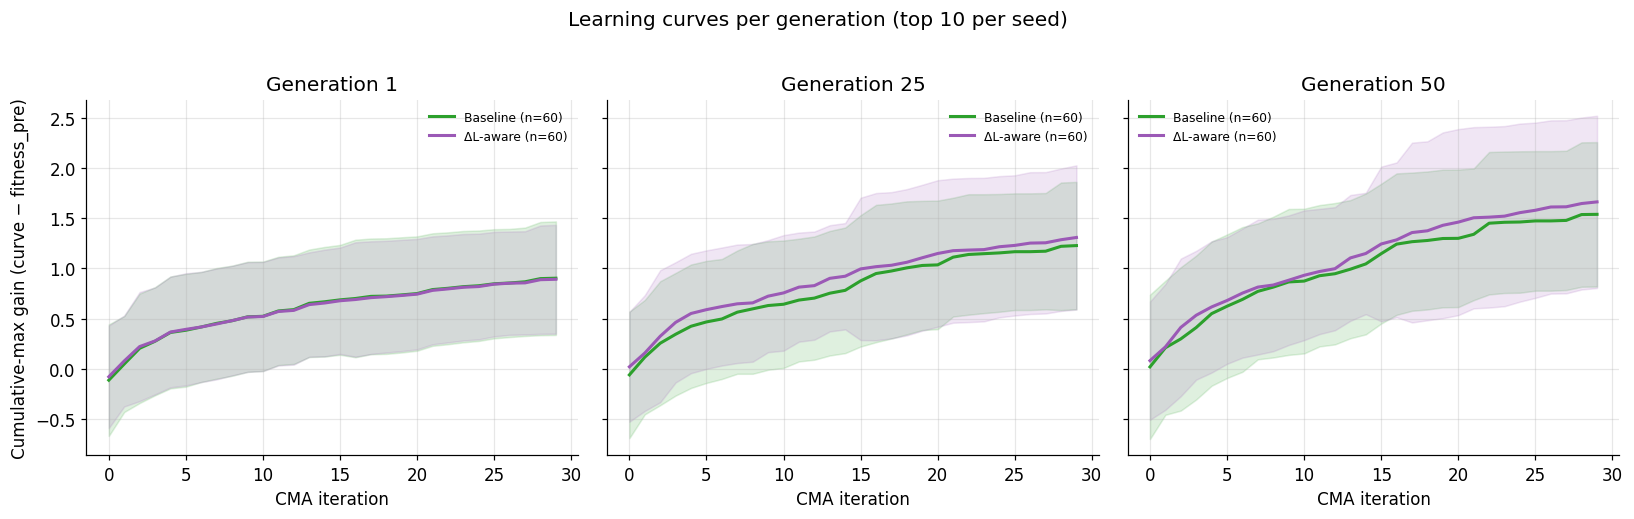

In [12]:

lc_top = (lc.sort_values("fitness", ascending=False)
          .groupby(["selection", "seed", "generation"], sort=False).head(10))
plot_learning_curves(lc_top, "Learning curves per generation (top 10 per seed)", "learning_curves_top10.pdf")


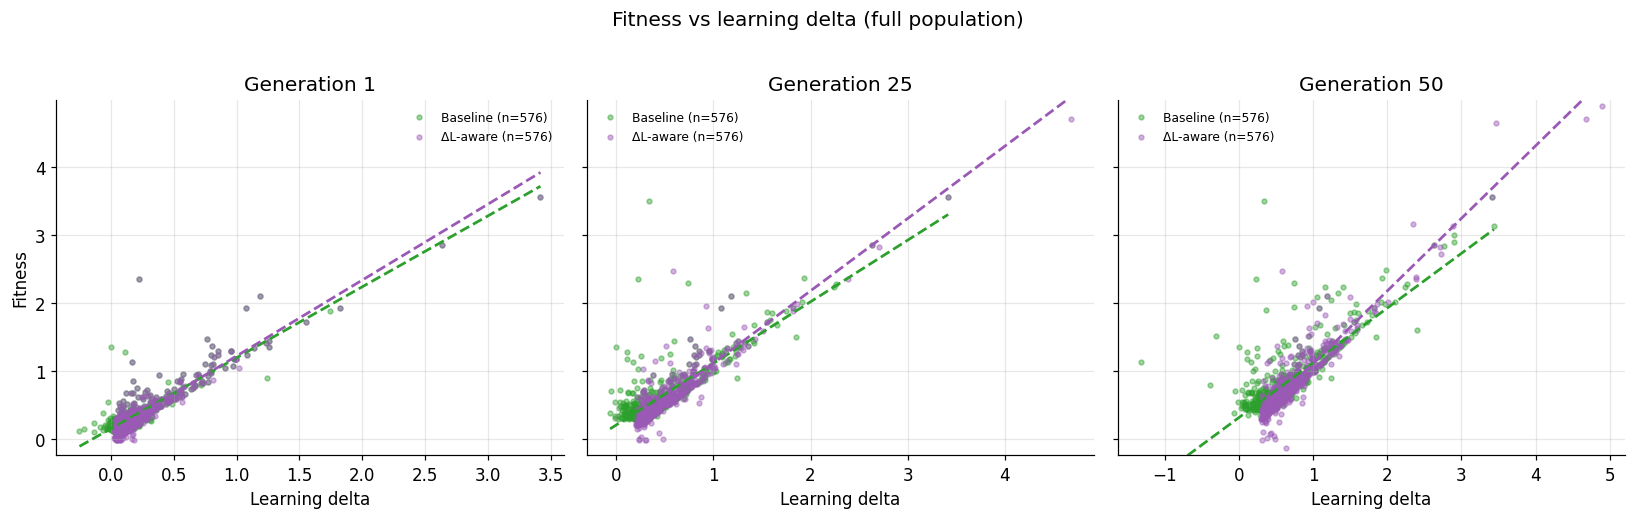

In [14]:

GENS_SCATTER = [1, 25, 50]
SCATTER_YLIM = (evo_f[evo_f.generation.isin(GENS_SCATTER)]["fitness"].min() - 0.1,
                evo_f[evo_f.generation.isin(GENS_SCATTER)]["fitness"].max() + 0.1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, gnum in zip(axes, GENS_SCATTER):
    for sel in SELECTIONS:
        sub = evo_f[(evo_f.selection == sel) & (evo_f.generation == gnum)]
        x = sub["ldelta"].values; y = sub["fitness"].values
        ax.scatter(x, y, s=10, color=COL[sel], alpha=0.45, label=f"{sel} (n={len(x)})")
        if len(x) > 2:
            b, a = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 50)
            ax.plot(xs, b * xs + a, color=COL[sel], lw=1.8, ls="--")
    ax.set_title(f"Generation {gnum}"); ax.set_xlabel("Learning delta")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Fitness"); axes[0].set_ylim(SCATTER_YLIM)
fig.suptitle("Fitness vs learning delta (full population)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "fitness_vs_ldelta_scatter.pdf"); plt.show()


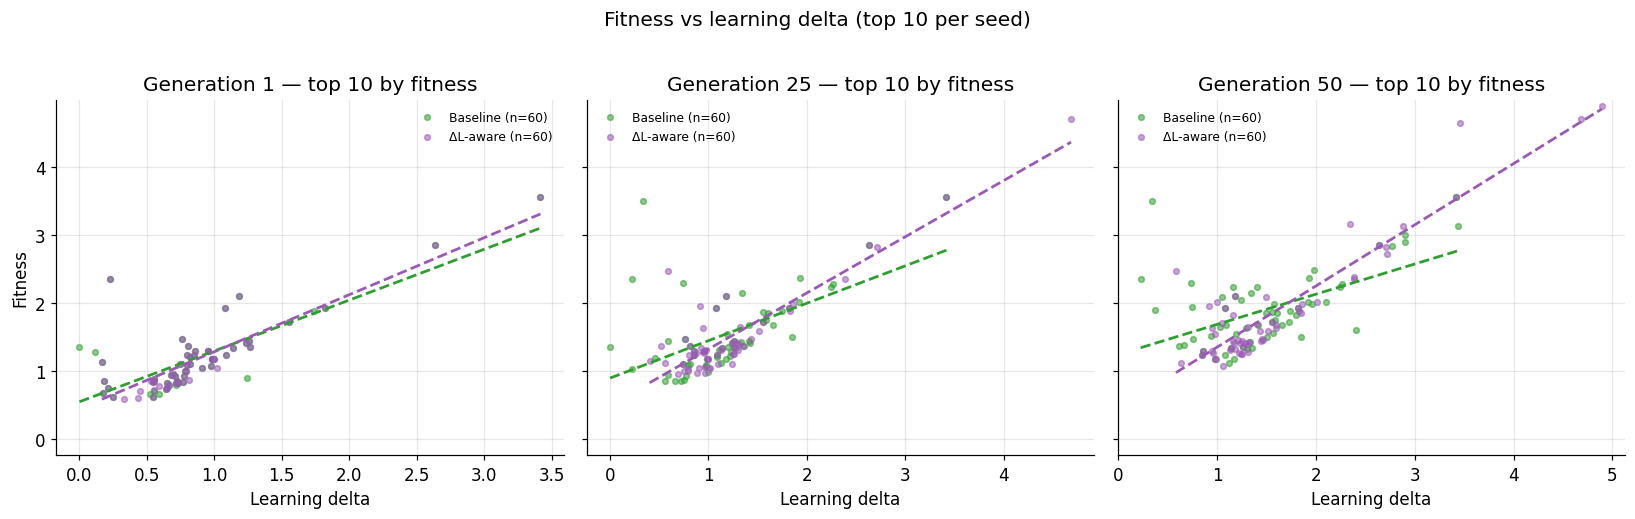

In [15]:

def top_per_seed(df, n=10):
    return df.sort_values("fitness", ascending=False).groupby(["selection", "seed"], sort=False).head(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, gnum in zip(axes, GENS_SCATTER):
    top = top_per_seed(evo_f[evo_f.generation == gnum], 10)
    for sel in SELECTIONS:
        sub = top[top.selection == sel]
        x = sub["ldelta"].values; y = sub["fitness"].values
        ax.scatter(x, y, s=14, color=COL[sel], alpha=0.55, label=f"{sel} (n={len(x)})")
        if len(x) > 2:
            b, a = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 50)
            ax.plot(xs, b * xs + a, color=COL[sel], lw=1.8, ls="--")
    ax.set_title(f"Generation {gnum} — top 10 by fitness"); ax.set_xlabel("Learning delta")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("Fitness"); axes[0].set_ylim(SCATTER_YLIM)
fig.suptitle("Fitness vs learning delta (top 10 per seed)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "fitness_vs_ldelta_scatter_top10.pdf"); plt.show()


## 4 · Generalization

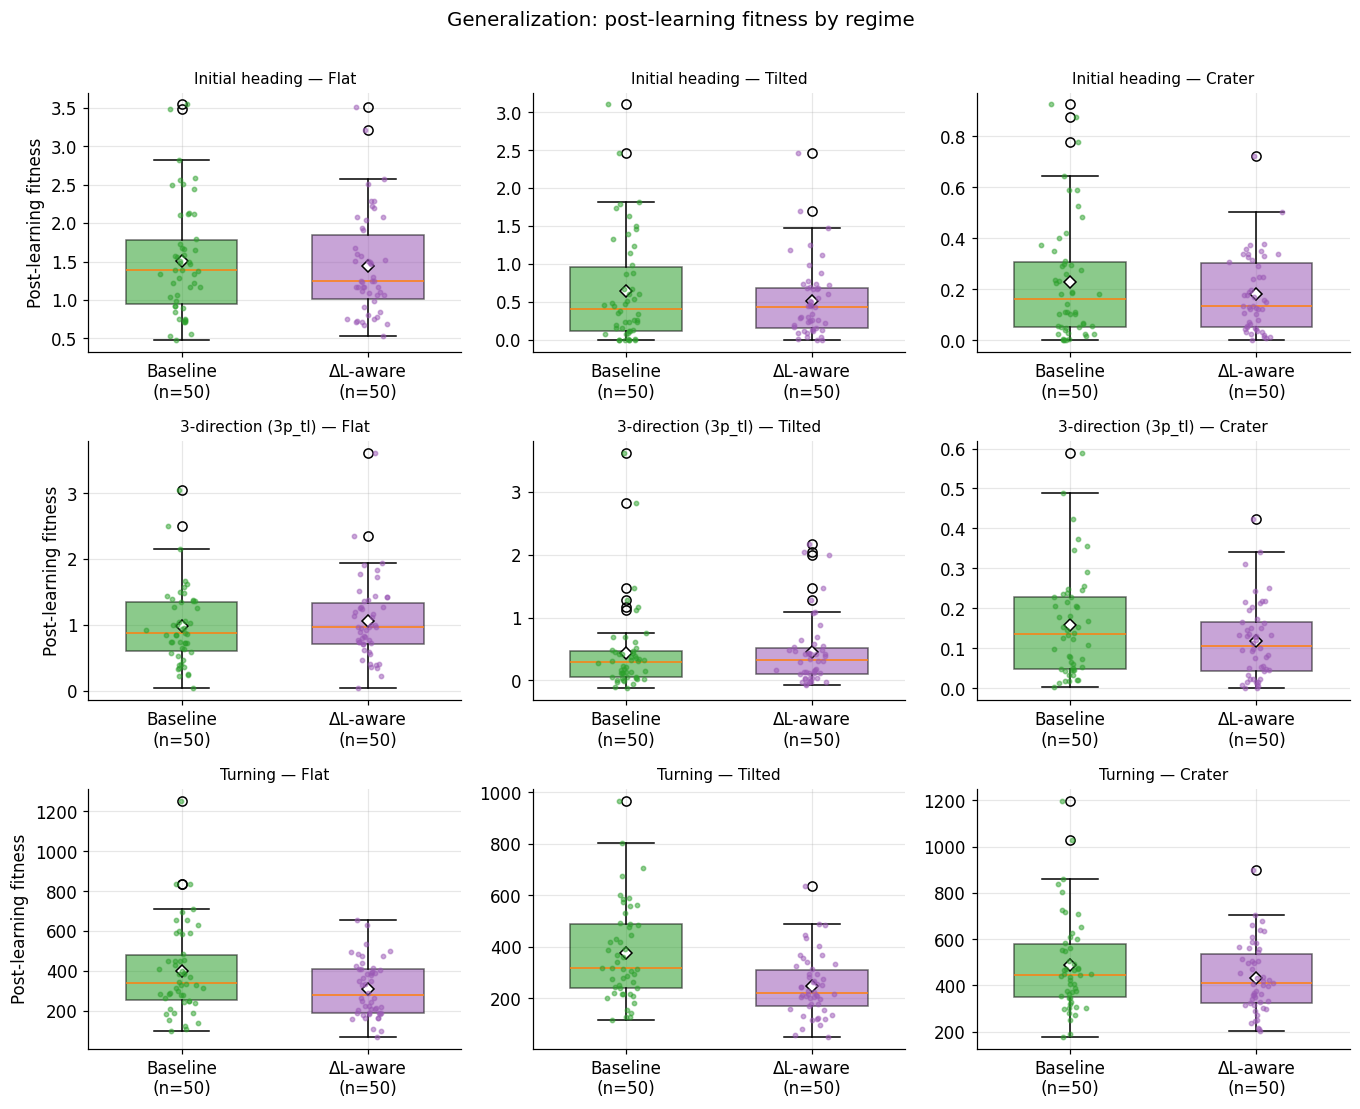

In [19]:

fig, axes = plt.subplots(len(OBJ_ORDER), len(TERR_ORDER), figsize=(12.5, 10))
rng_jit = np.random.default_rng(0)
for i, obj in enumerate(OBJ_ORDER):
    for j, terr in enumerate(TERR_ORDER):
        ax = axes[i, j]; data = []
        for sel in SELECTIONS:
            v = gen_f[(gen_f.objective == obj) & (gen_f.terrain == terr) &
                      (gen_f.selection == sel)]["fitness"].values
            data.append(v)
        bp = ax.boxplot(data, tick_labels=[f"{c}\n(n={len(d)})" for c, d in zip(SELECTIONS, data)],
                        patch_artist=True, showmeans=True, widths=0.6,
                        meanprops=dict(marker="D", markerfacecolor="white",
                                       markeredgecolor="black", markersize=6))
        for patch, sel in zip(bp["boxes"], SELECTIONS):
            patch.set_facecolor(COL[sel]); patch.set_alpha(0.55)
        for k, v in enumerate(data):
            ax.scatter(rng_jit.normal(k + 1, 0.05, len(v)), v, s=8,
                       color=COL[SELECTIONS[k]], alpha=0.5, zorder=3)
        ax.set_title(f"{OBJ_LABEL[obj]} — {TERR_LABEL[terr]}", fontsize=10)
        if j == 0:
            ax.set_ylabel("Post-learning fitness")
fig.suptitle("Generalization: post-learning fitness by regime", y=1.005, fontsize=13)
fig.tight_layout(); fig.savefig(FIG_DIR / "generalization_boxplots.pdf"); plt.show()


## 5 · Morphological analysis (final generation)

In [20]:

import sys as _sys
_sys.path.insert(0, str(ROOT / "ariel" / "src"))
_sys.path.insert(0, str(ROOT / "ariel"))
import torch as _torch
import EA_FINAL_ga as EA
from ariel.utils.morphological_descriptor import MorphologicalMeasures

MIRAS = ["limbs", "length_of_limbs", "coverage", "symmetry", "joints"]
MORPH_DESCS = ["branching", "limb_std"] + MIRAS

def load_final_morph():
    rows = []
    for f in sorted(EXP_DIR.glob("learning*_ga_p2_*_flat.csv")):
        m = EVO_RE.search(f.name)
        if not m:
            continue
        seed, sel = int(m.group(1)), SEL_FROM_TAG[m.group(2)]
        _torch.manual_seed(seed); np.random.seed(seed)
        NDE = EA.nde(number_of_modules=EA.NMODULES, genotype_size=EA.GENE_SIZE_NDE)
        DECODER = EA.whpd(num_modules=EA.NMODULES)
        df = pd.read_csv(f, usecols=["generation", "genotype"])
        df = df[df["generation"] == df["generation"].max()]
        for _, r in df.iterrows():
            rec = {"selection": sel, "seed": seed}
            try:
                ind = EA.Individual(); ind.genotype = parse_list(r["genotype"])
                robot = EA._decode_robot_no_overlap(ind, NDE=NDE, DECODER=DECODER,
                                                    world_cls=EA.SimpleFlatWorld, SEED=seed)
                bm = EA.get_measures(robot)
                rec["branching"], rec["limb_std"] = float(bm[0]), float(bm[1])
                mm = MorphologicalMeasures(robot.body_phenotype)
                for d in MIRAS:
                    try:
                        rec[d] = float(getattr(mm, d))
                    except Exception:
                        rec[d] = np.nan
            except Exception:
                pass
            for d in MORPH_DESCS:
                rec.setdefault(d, np.nan)
            rows.append(rec)
    return pd.DataFrame(rows)

morph = load_final_morph()


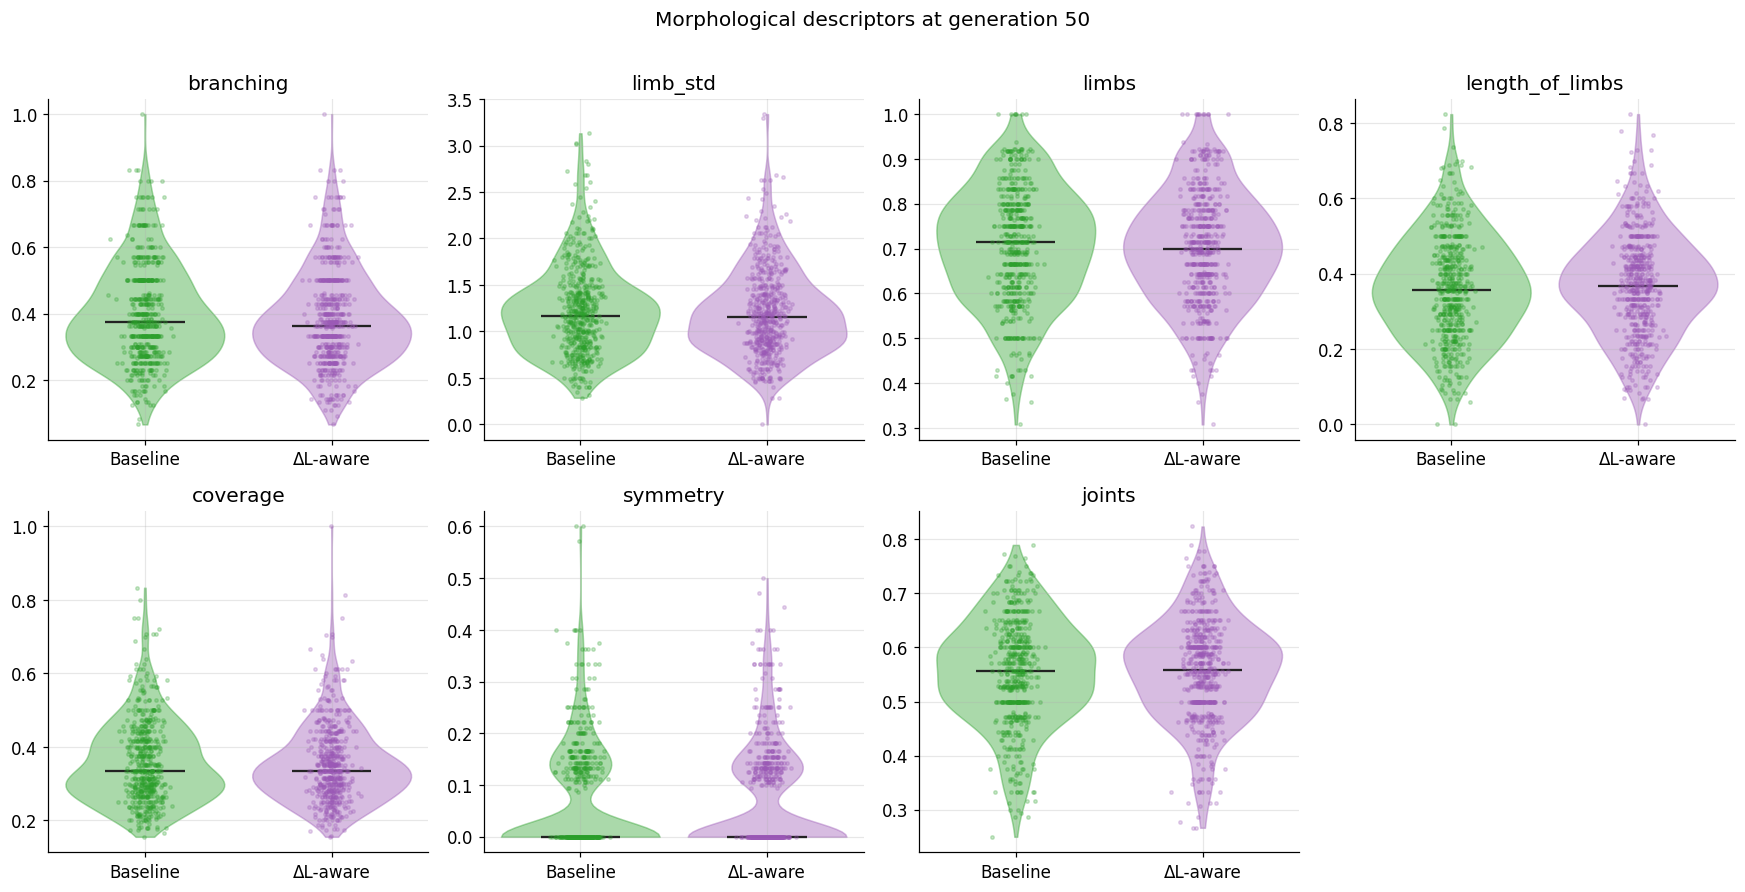

In [21]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
rng_jit = np.random.default_rng(0)
for ax, d in zip(axes.ravel(), MORPH_DESCS):
    data = [morph[morph.selection == sel][d].dropna().values for sel in SELECTIONS]
    parts = ax.violinplot(data, positions=[1, 2], widths=0.85, showmedians=True, showextrema=False)
    for body, sel in zip(parts["bodies"], SELECTIONS):
        body.set_facecolor(COL[sel]); body.set_alpha(0.40); body.set_edgecolor(COL[sel])
    if "cmedians" in parts:
        parts["cmedians"].set_color("#222"); parts["cmedians"].set_linewidth(1.5)
    for k, (v, sel) in enumerate(zip(data, SELECTIONS), start=1):
        ax.scatter(rng_jit.normal(k, 0.05, len(v)), v, s=5, color=COL[sel], alpha=0.25, zorder=3)
    ax.set_xticks([1, 2]); ax.set_xticklabels(SELECTIONS); ax.set_title(d)
for ax in axes.ravel()[len(MORPH_DESCS):]:
    ax.axis("off")
fig.suptitle(f"Morphological descriptors at generation {GEN_LAST}", y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR / "morphology_final_gen.pdf"); plt.show()
